In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapy as media

In [2]:
def clamp_from_0_to_1(matrix:np.ndarray):
    # Takes each value, minuses it by the min,
    #   and then uses range (from peak to peak) to clamp it from 0 to 1.
    return (matrix - matrix.min()) / np.ptp(matrix)

In [3]:
def sum_matrix_to_1(matrix:np.ndarray):
    # each value - min, divided by the sum of each value - min
    #   clamps the values and makes it all sum to 1
    return (matrix - matrix.min()) / (matrix - matrix.min()).sum()

In [4]:
def pad_with_zeros(matrix:np.ndarray, window_size:int=3):
    if window_size % 2 != 1 or window_size < 3:
        raise ValueError("Window size must be odd and >= 3")
    half_window = window_size//2
    new_matrix = np.zeros((matrix.shape[0] + window_size - 1, matrix.shape[1] + window_size - 1), dtype=matrix.dtype)
    new_matrix[half_window:(new_matrix.shape[0] - half_window), half_window:(new_matrix.shape[1] - half_window)] = matrix
    return new_matrix

In [5]:
def filter_image(input_img, filter_kernel):
    """
    Return the convolution result: image * kernel.
    Caution: use zero-padding.

    :param input_img: H x W
    :param filter_kernel: h x w
    :returns convolve: H x W
    """
    if len(filter_kernel.shape) != 2 \
            or filter_kernel.shape[0] != filter_kernel.shape[1] \
            or filter_kernel.shape[0] % 2 != 1:
        raise ValueError("Filter provided is not a 2D square matrix w/ odd dim.s")

    filter_half = filter_kernel.shape[0] // 2
    padded_input = pad_with_zeros(input_img, filter_kernel.shape[0])
    output = np.zeros(input_img.shape, dtype='float64')
    for i in range(filter_half, padded_input.shape[0] - filter_half):
        for j in range(filter_half, padded_input.shape[1] - filter_half):
            window = padded_input[i - filter_half:i + filter_half + 1, j - filter_half:j + filter_half + 1]
            output_value = np.sum(window * filter_kernel)
            output[i - filter_half, j - filter_half] = output_value
    return output

In [6]:
def sobel_operator(image: np.ndarray):
    """
    Return Gx, Gy, and the gradient magnitude.

    :param image: H x W
    :returns g_x, g_y, grad_magnitude: H x W
    """
    m_x = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]])
    m_y = np.array([[1, 2, 1],
                   [0, 0, 0],
                   [-1, -2, -1]])
    image_norm = image.astype(np.float64)
    g_x = np.abs(filter_image(image_norm, m_x))
    g_y = np.abs(filter_image(image_norm, m_y))
    grad_magnitude = np.sqrt(np.power(g_x, 2) + np.power(g_y, 2))

    return g_x, g_y, grad_magnitude

In [7]:
def generate_gaussian(sigma):
    """
    Return kernel of appropriate size
    Caution: coefficients must sum to 1

    :param sigma: scalar (should be positive but it will be squared anyway)
    :returns kernel: W x W (no need to return W)
    """
    kernel_size = 35
    center_coord = kernel_size // 2
    kernel = np.zeros((kernel_size,kernel_size), dtype='float64')
    for i in range(kernel_size):
        coord = i - center_coord
        value = (1 / (np.sqrt(2 * np.pi) * sigma))
        value *= np.exp(-1 * np.power(coord, 2)/(2 * np.power(sigma, 2)))
        kernel[i] = value
    return sum_matrix_to_1(kernel @ kernel.T)

In [8]:
def harris_detector(image, window_size=5):
    """
    Given an input image, calculate the Harris Detector score for all pixels
    Use zero-padding to handle boundaries

    :param image: H x W
    :param window_size: odd >= 1 integer
    :returns results: a image of size H x W
    """

    if window_size % 2 != 1 or window_size < 1:
        raise ValueError("window_size must be odd and >= 1")
    half_window = window_size//2

    alpha = 0.06

    # compute partial derivatives Ix and Iy at each pixel
    # gauss_kernel = generate_gaussian(4.0)
    # image_gauss = filter_image(image, gauss_kernel)
    # i_x, i_y, _ = sobel_operator(image_gauss)
    i_x, i_y, _ = sobel_operator(image)

    i_xx = i_x * i_x
    i_yy = i_y * i_y
    i_xy = i_x * i_y

    i_xx = pad_with_zeros(i_xx, window_size)
    i_yy = pad_with_zeros(i_yy, window_size)
    i_xy = pad_with_zeros(i_xy, window_size)

    # compute a second moment matrix in a window around each pixel
    # compute a corner response function R = det(M) - alpha*trace(M)^2
    corner_response = np.zeros(image.shape, dtype=np.float64)
    for x in range(0, corner_response.shape[0]):
        for y in range(0, corner_response.shape[1]):
            # making second moment as components, directly computing R afterwards
            sum_i_xx = i_xx[(x - half_window):(x + half_window + 1), (y - half_window):(y + half_window + 1)].sum()
            sum_i_xy = i_xy[(x - half_window):(x + half_window + 1), (y - half_window):(y + half_window + 1)].sum()
            sum_i_yy = i_yy[(x - half_window):(x + half_window + 1), (y - half_window):(y + half_window + 1)].sum()

            det_smm = sum_i_xx*sum_i_yy - np.power(sum_i_xy, 2)
            trace_smm_pow_2 = np.power(sum_i_xx + sum_i_xy, 2)
            corner_response[x,y] = det_smm - (alpha * trace_smm_pow_2)

    return corner_response

In [9]:
def nms(image):
    """
    Non-max suppression in 3x3 windows.
    Use zero-padding.

    :param image: H x W
    :returns nms_image: H x W
    """
    window_size = 3
    window_half = window_size//2

    padded_image = pad_with_zeros(image, window_size)
    nms_image = np.zeros(image.shape, dtype=np.float64)

    # only keep the local maxes!!
    for x in range(window_half, padded_image.shape[0] - window_half):
        for y in range(window_half, nms_image.shape[1] - window_half):
            window = padded_image[
                     (x-window_half):(x+window_half+1),
                     (y-window_half):(y+window_half+1)].flatten()
            center = window[(window_size * window_half) + window_half]
            window = np.delete(window, (window_size * window_half) + window_half, 0)
            window = np.vectorize(lambda cell: center > cell)(window)
            if np.all(window):
                nms_image[x-window_half, y-window_half] = padded_image[x,y]

    return nms_image

In [10]:
def threshold_nms(image:np.ndarray, percent:float):
    """
    Applies thresholding to all points in a given NMS suppressed, harris-detected image.

    :param image: 2d matrix image, represented as a numpy ndarray
    :param percent: an integer for the percent to threshold
    :return: output: a new 2d matrix image, without modifying the original
    """
    if percent < 0 or percent > 1:
        raise ValueError("percent must be a float between 0 and 1")
    output = image.copy()
    threshold_amt = ((output.max() - output.min()) * percent) + output.min()
    for x in range(output.shape[0]):
        for y in range(output.shape[1]):
            output[x,y] = output[x,y] if output[x,y] > threshold_amt else 0

    return output

In [11]:
def display_threshold_nms_as_binary(image:np.ndarray):
    """
    Takes an output from threshold_nms and makes it easier to see the points,
        by displaying them as only white dots.
    :param image: a 2D image represented as a numpy ndarray
    :return output: a 2D image, removed from the original
    """
    output = np.zeros(shape=(image.shape[0], image.shape[1]))
    for x in range(output.shape[0]):
        for y in range(output.shape[1]):
            output[x,y] = 255 if image[x,y] != 0 else 0

    return output

In [12]:
def display_threshold_nms_as_red(image:np.ndarray):
    """
    Takes an output from threshold_nms and makes it easier to see the points,
        by displaying them as red dots.
    :param image: a 2D image represented as a numpy ndarray
    :return output: a 2D image, removed from the original
    """
    output = np.zeros(shape=(image.shape[0], image.shape[1], 3))
    for x in range(output.shape[0]):
        for y in range(output.shape[1]):
            output[x,y] = [255, 0, 0] if image[x,y] != 0 else [0, 0, 0]

    return output

In [13]:
def overlay_harris_nms_threshold_on_image(red_threshold:np.ndarray, orig_image:np.ndarray):
    """
    Takes an nms threshold of a harris operator, and overlays it on the original image
        it is based on to make it easier to see the corners
    :param red_threshold: a 2D RGB Image Matrix, with red dots
    :param orig_image: a 2D Grayscale Image Matrix
    :return output: a 2D RGB Image Matrix, with black-bordered red dots for the corners
    """
    window_size = 7
    half_window = window_size//2

    if len(red_threshold.shape) != 3:
        raise ValueError("red_threshold must be a 2D RGB image matrix")
    if len(orig_image.shape) != 2:
        raise ValueError("orig_image must be a 2D grayscale image matrix")
    output = np.zeros((orig_image.shape[0], orig_image.shape[1], 3), dtype=np.uint8)
    for x in range(output.shape[0]):
        for y in range(output.shape[1]):
            value = orig_image[x,y]
            output[x,y] = np.array([value, value, value])
    for x in range(output.shape[0]):
        for y in range(output.shape[1]):
            col_start, col_end = max(0, x-half_window), min(x+half_window, output.shape[0])
            row_start, row_end = max(0, y-half_window), min(y+half_window, output.shape[1])
            red_col_start, red_col_end = max(col_start, x-half_window+1), min(x+half_window-1, col_end)
            red_row_start, red_row_end = max(row_start, y-half_window+1), min(y+half_window-1, row_end)
            # Print a windowed red dot with a black border, to spot the corners easily
            if red_threshold[x,y,0] != 0:
                output[col_start:col_end, row_start:row_end] = red_threshold[col_start:col_end, row_start:row_end]
                output[red_col_start:red_col_end, red_row_start:red_row_end] = [255,0,0]
    return output

In [14]:
def imshow(image:np.ndarray, *args, **kwargs):
    # Cast, we might have a floating point image.
    image = np.copy(image)
    if image.min() < 0 or image.max() > 255 or not np.isdtype(image.dtype, np.uint8):
        print("Image not properly formatted. Clamping & formatting as uint8...")
        image = clamp_from_0_to_1(image) * 255
        image = image.astype(np.uint8)
    if len(image.shape) == 3:
        # Height, width, channels
        # Assume BGR, do a conversion since
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    else:
        # Height, width - must be grayscale
        # convert to RGB, since matplotlib will plot in a weird colormap (instead of black = 0, white = 1)
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    # Draw the image
    plt.imshow(image, *args, **kwargs)
    # We'll also disable drawing the axes and tick marks in the plot, since it's actually an image
    plt.axis('off')
    # Make sure it outputs
    plt.show()


"Original Image, Converted to Grayscale"

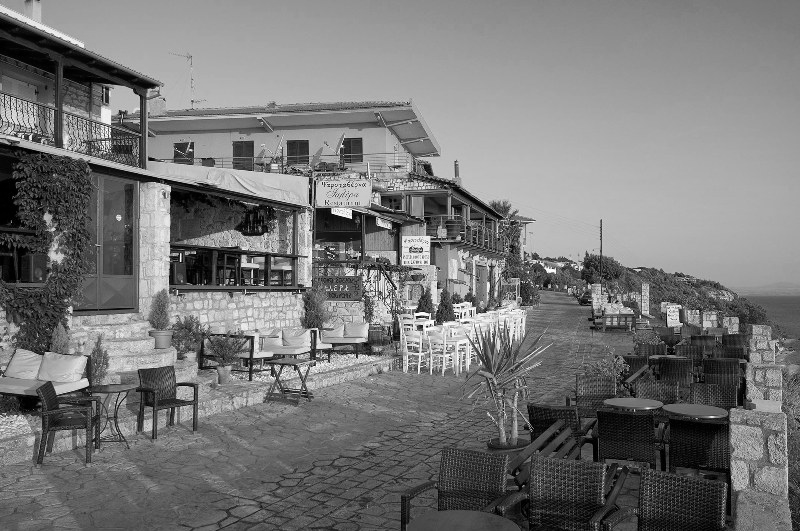

Absolute values of the response to the horizontal and vertical Sobel filters


Horizontal Sobel Output,Vertical Sobel Output

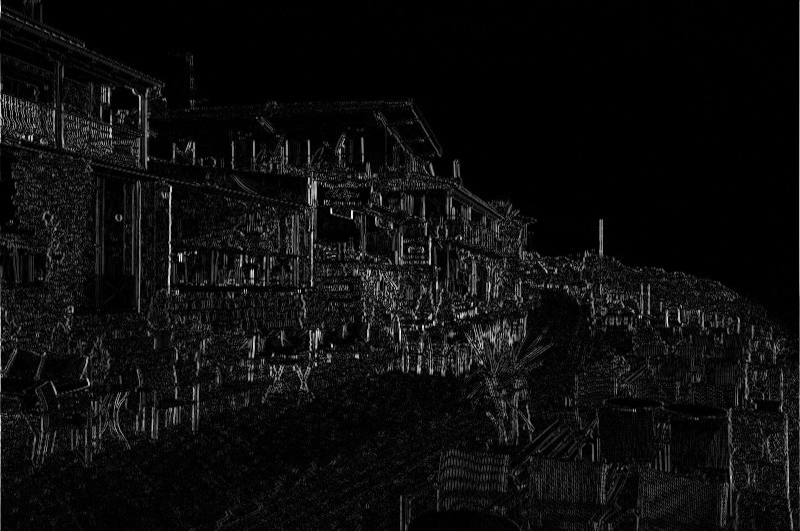
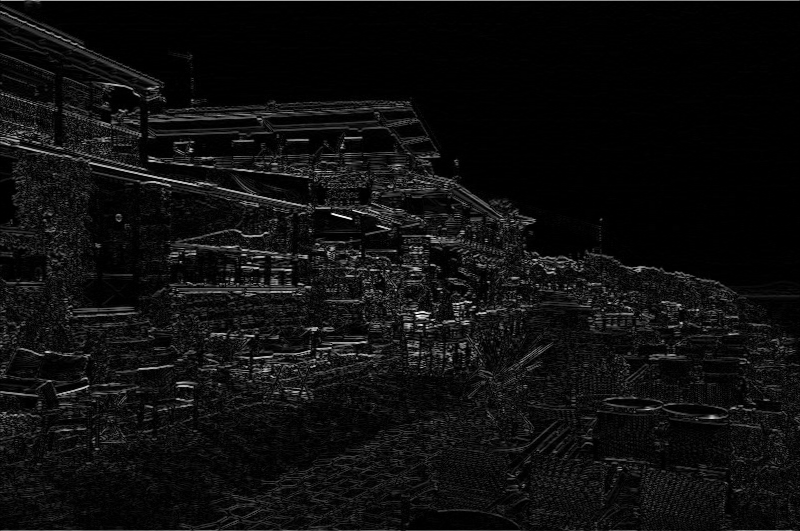

Sobel Gradient Magnitude

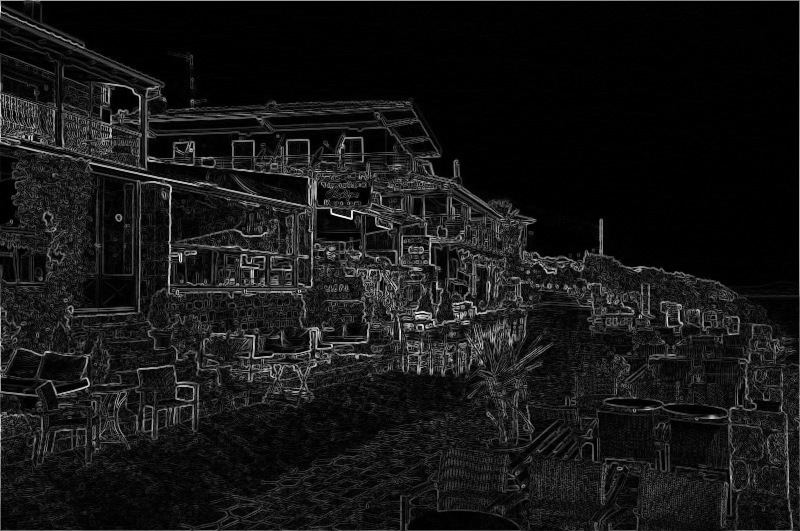

Kernel @ Sigma 1,Kernel @ Sigma 2,Kernel @ Sigma 3,Kernel @ Sigma 4,Kernel @ Sigma 5,Kernel @ Sigma 6,Kernel @ Sigma 7,Kernel @ Sigma 8,Kernel @ Sigma 9,Kernel @ Sigma 10

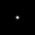
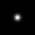
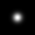
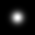
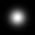
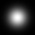
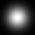
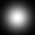
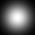
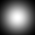

Image w/ Gaussian Filter (Sigma 2.0)

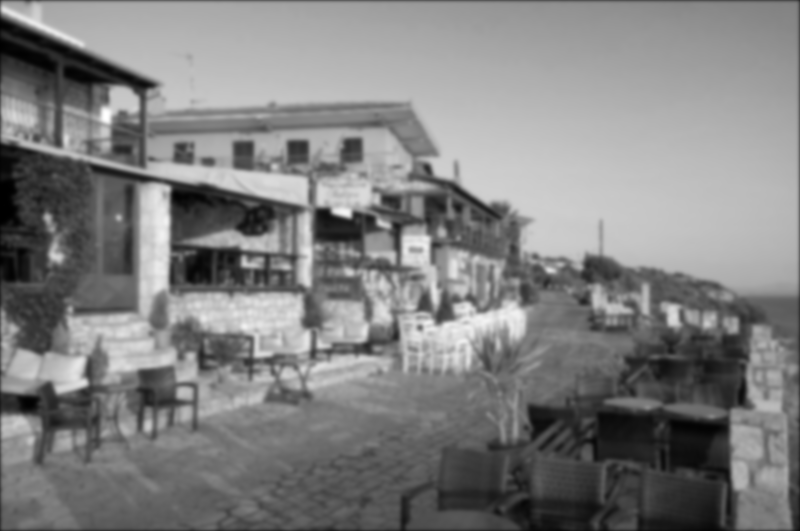

Edge gradient magnitude after Gaussian filtering


""

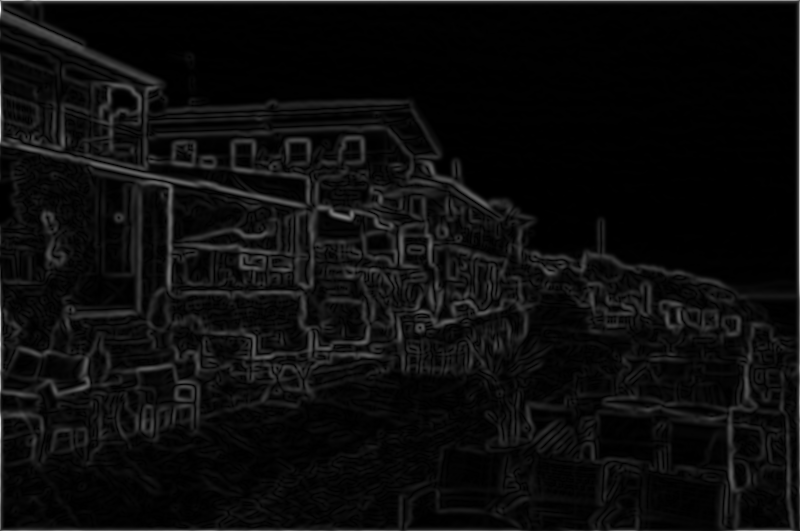

Magnitude of Harris operator


Harris Operator Magnitude

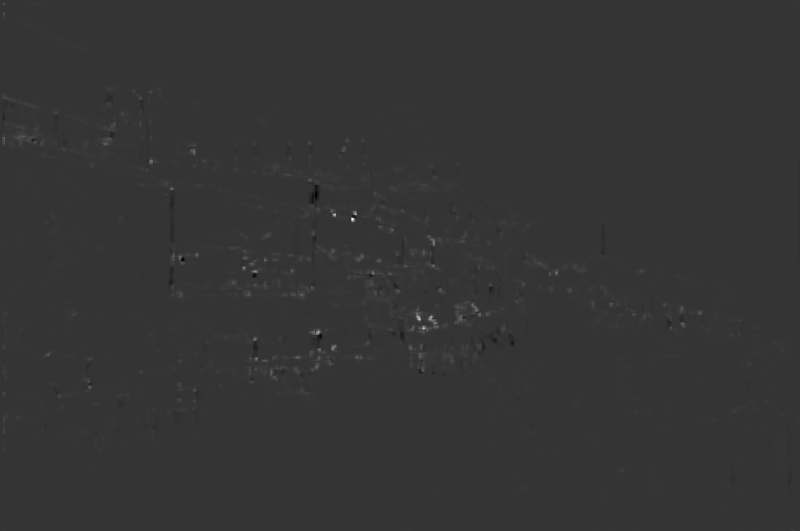

Non-Maximum Suppression, with & without Thresholding


Non-Maximum Suppression

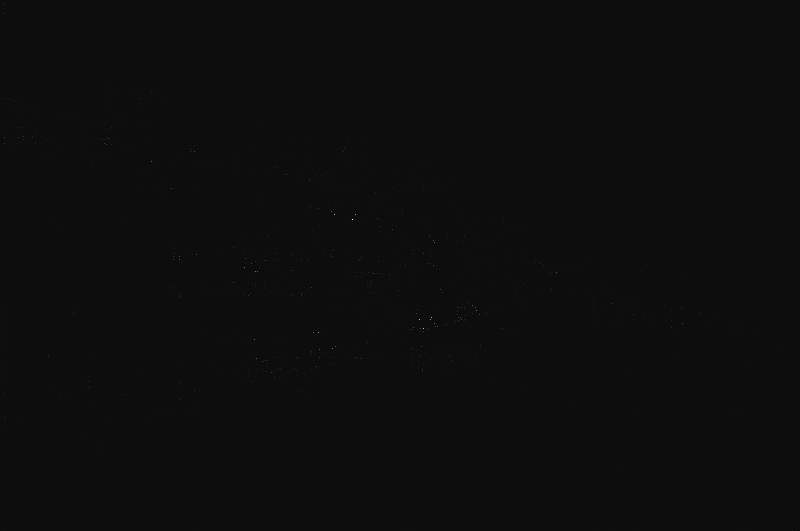

Non-Maximum Suppression W/ 10.00% Thresholding

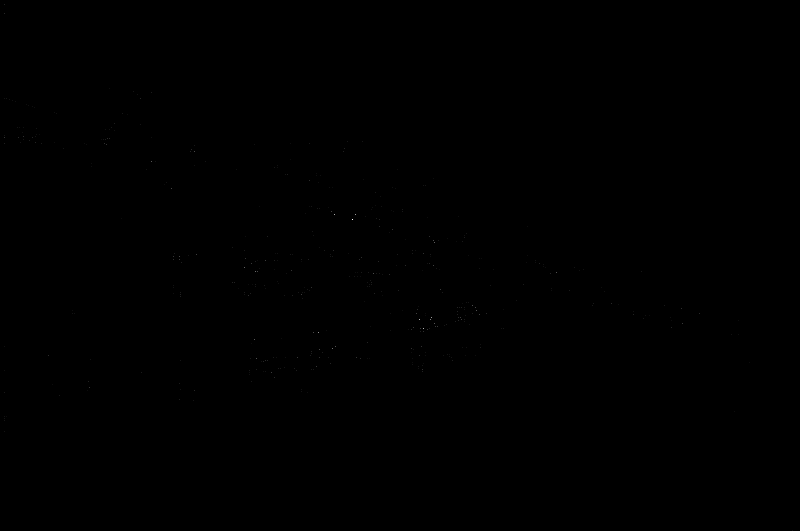

Corner locations marked as red, easier to spot


"NMS w/ Thresholding, as Bright White Dots"

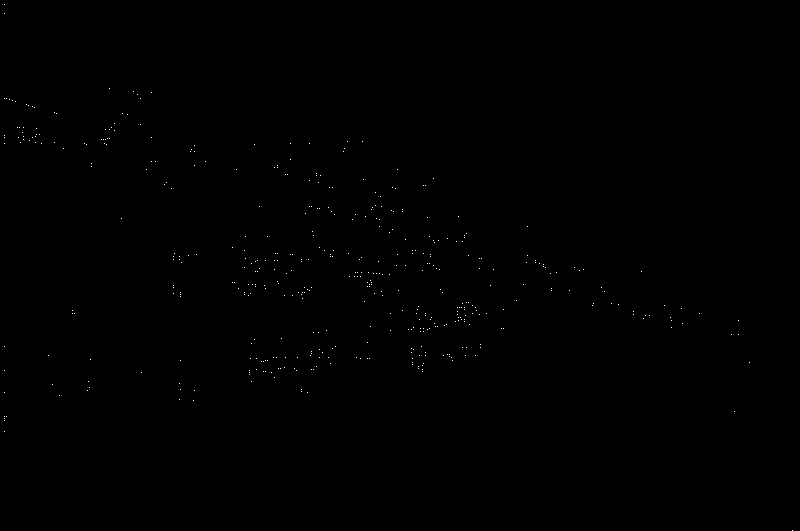

Corners superimposed on input image


"NMS w/ Thresholding, on top of Image Input"

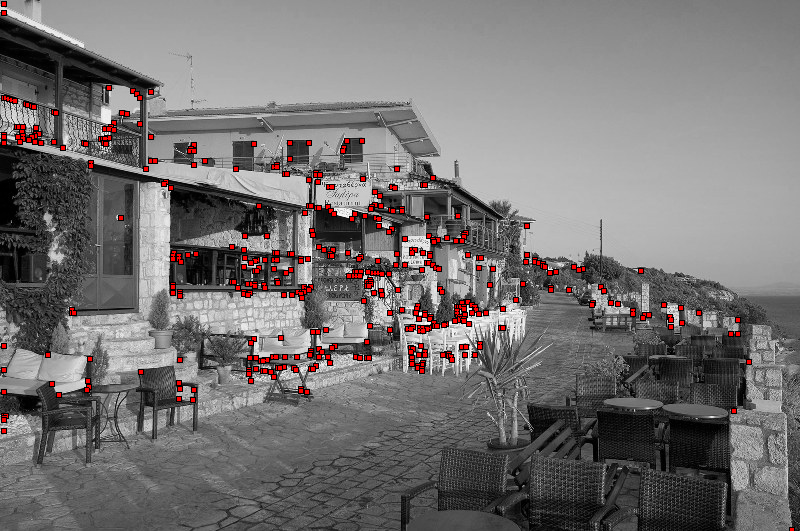

In [15]:
def main():
    # NOTE TO TAs
    # I ran this on a local Jupyter Notebook with JetBrains, hence the reason for this extra
    #   image read logic. If you're using Google Colab, feel free to change `using_local_image_file` to False,
    #   and change rootpath to your appropriate GDrive rootpath.
    using_local_image_file = True
    if using_local_image_file:
        rootpath = './'
        input_image = cv2.imread(os.path.join(rootpath, "village3.jpg"))
        input_image = cv2.cvtColor(input_image, cv2.COLOR_BGR2GRAY)
        media.show_image(input_image, title='Original Image, Converted to Grayscale')
    else:
        from google.colab import drive
        drive.mount('/content/gdrive', force_remount=True)
        rootpath = '/content/gdrive/MyDrive/cs558_resources/6.869_python_tutorial/6.869_python_tutorial'
        input_image = cv2.imread(os.path.join(rootpath, "phoenix.jpg"))
        input_image = cv2.cvtColor(input_image, cv2.COLOR_BGR2GRAY)
        media.show_image(input_image, title='Original Image, Converted to GrayScale')

    # Step 1
    # Sobel filter
    g_x, g_y, grad_mag = sobel_operator(input_image)
    print('Absolute values of the response to the horizontal and vertical Sobel filters')
    media.show_images({
        'Horizontal Sobel Output': g_x,
        'Vertical Sobel Output': g_y})
    media.show_image(grad_mag, title='Sobel Gradient Magnitude')
    # display

    # Step 2
    # Gaussian filter
    sigmas = list(range(1, 11))
    kernels = {f'Kernel @ Sigma {sig}': generate_gaussian(sig) for sig in sigmas}
    media.show_images(kernels, height=100)

    sigma = 2.0
    kernel = generate_gaussian(sigma)
    image_gauss= filter_image(input_image, kernel)
    # print('Image after Gaussian filtering')
    media.show_image(image_gauss, title=f'Image w/ Gaussian Filter (Sigma {sigma})')

    # Step 3
    # smooth and compute derivatives
    # display only final output - we have already seen intermediate results
    image_sobel_gauss = filter_image(input_image, kernel)
    _, _, isg_mag = sobel_operator(image_sobel_gauss)
    print('Edge gradient magnitude after Gaussian filtering')
    media.show_image(isg_mag)

    # Step 4
    # Harris operator
    win_size = 5
    harris_resp = harris_detector(input_image, win_size)
    print('Magnitude of Harris operator')
    media.show_image(harris_resp, title="Harris Operator Magnitude")

    # Step 5
    print("Non-Maximum Suppression, with & without Thresholding")
    # NMS, Thresholding and super-imposing corners on input
    # You may implement this here or as separate function(s)
    image_nms = nms(harris_resp)
    threshold = 0.10
    image_nms_threshold = threshold_nms(image_nms, threshold)
    media.show_image(image_nms, title='Non-Maximum Suppression')
    media.show_image(image_nms_threshold, title=f'Non-Maximum Suppression W/ {threshold:.2%} Thresholding')

    print('Corner locations marked as red, easier to spot')
    image_nms_threshold_binary = display_threshold_nms_as_binary(image_nms_threshold)

    media.show_images({
        'NMS w/ Thresholding, as Bright White Dots': image_nms_threshold_binary})
    print('Corners superimposed on input image')
    image_nms_threshold_red = display_threshold_nms_as_red(image_nms_threshold)
    image_nms_overlay = overlay_harris_nms_threshold_on_image(image_nms_threshold_red, input_image)
    media.show_image(image_nms_overlay, title="NMS w/ Thresholding, on top of Image Input")

main()